# Driver Monitoring System — Eating & Drinking Detection Module

This notebook covers the eating/drinking detection module of the DMS graduation project. Like the other modules (smoking, seatbelt, drowsiness), it treats the problem as single-class object detection: given a frame from the driver-facing camera, detect whether the driver is eating or drinking while driving.

The dataset is pulled directly from Roboflow, and the model is a YOLOv8n detector, chosen here for faster iteration while testing the pipeline end to end. The notebook is structured in six parts: download the dataset, take a quick look at it, train, run EDA on the training results, test on the test set, and finally test on one external image.

## 0. Environment Setup

Installs the two packages this notebook depends on: `roboflow`, to pull the dataset straight from the Roboflow project, and `ultralytics`, for YOLOv8 training and inference.

In [1]:
!pip install roboflow ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.2 MB/s eta 0:00:00


## 1. Download Dataset

The dataset is hosted on Roboflow (`eating-and-drinking-quux5`, version 6) and is downloaded in YOLOv8 format, which gives the standard `train/valid/test` folder layout with a `data.yaml` describing the class(es). `dataset.location` holds the local path once the download finishes, and is reused throughout the rest of the notebook.

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="xcDJdDJpIdytumuUX8pM")
project = rf.workspace("yurals-pro").project("eating-and-drinking-quux5")
version = project.version(6)
dataset = version.download("yolov8")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Eating-and-Drinking--6 in yolov8:: 100%|██████████| 6060/6060 [00:02<00:00, 2204.95it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
/content/Eating-and-Drinking--6


## 2. Quick Look at the Dataset

Before training anything, it's worth loading `data.yaml` to confirm the class list is what's expected, and visually checking a handful of annotated images to make sure the boxes actually correspond to eating/drinking behavior rather than something mislabeled.

In [3]:
import os, yaml

data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)
print(data_cfg)

{'names': ['eating'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'eating-and-drinking-quux5', 'url': 'https://universe.roboflow.com/yurals-pro/eating-and-drinking-quux5/dataset/6', 'version': 6, 'workspace': 'yurals-pro'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


### Visualize a Few Annotated Samples

Draws the YOLO-format bounding boxes on top of 6 random training images. This is a manual check — if the boxes look off here, it's better to catch it now than after a full training run.

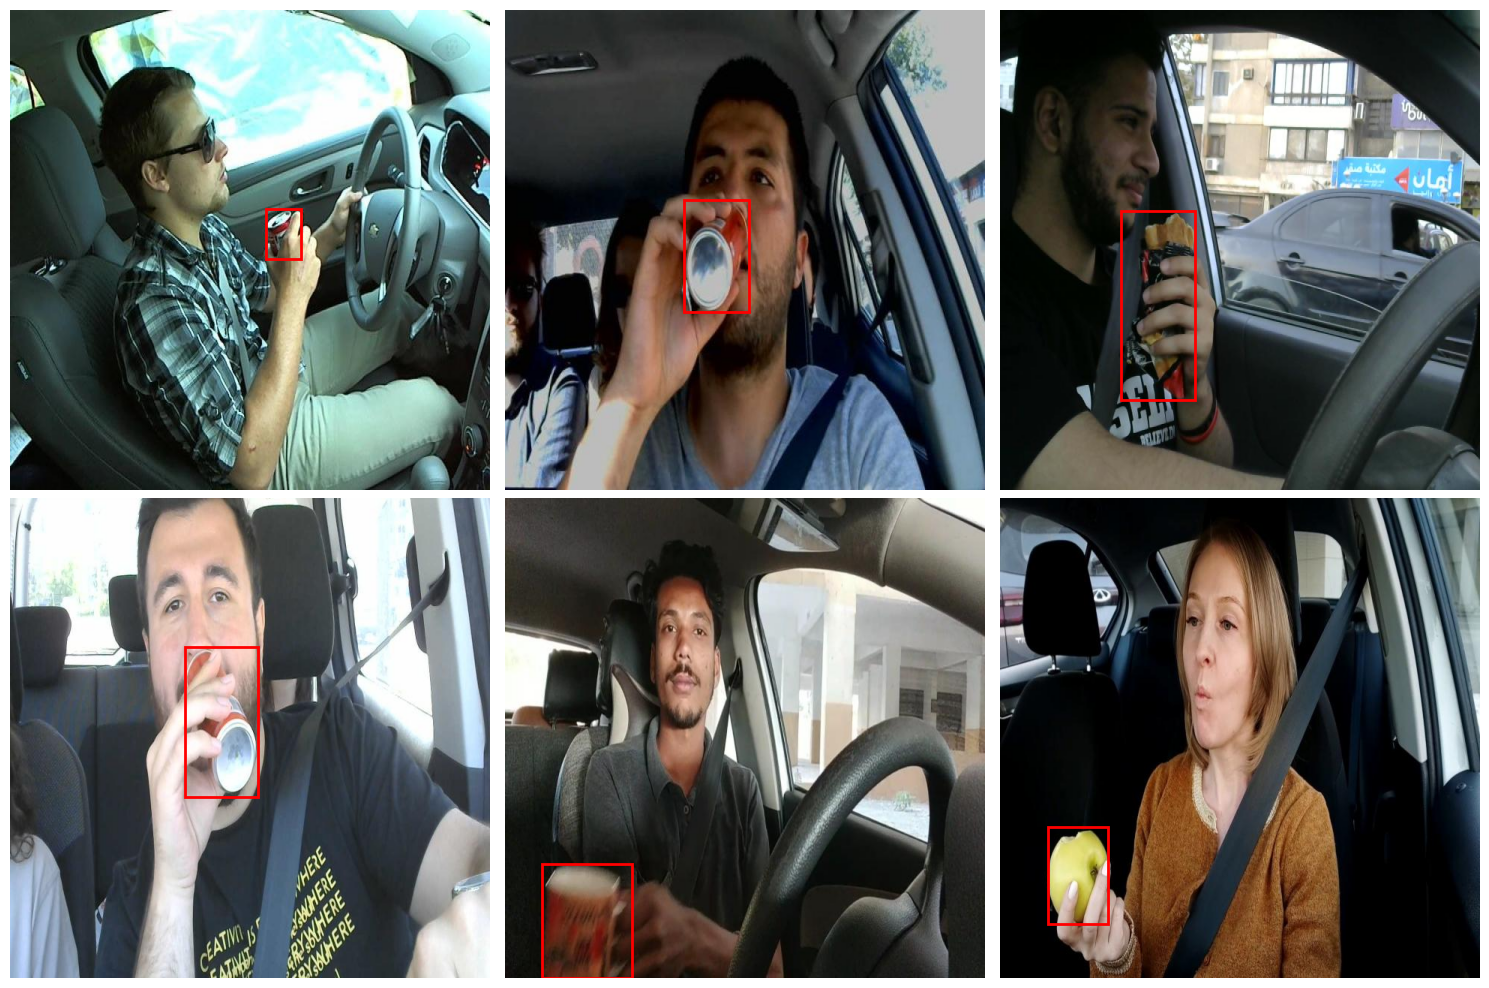

In [4]:
import glob, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

train_images_dir = os.path.join(dataset.location, "train", "images")
train_labels_dir = os.path.join(dataset.location, "train", "labels")

image_files = glob.glob(os.path.join(train_images_dir, "*.jpg")) + glob.glob(os.path.join(train_images_dir, "*.png"))
sample_files = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), sample_files):
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    label_path = os.path.join(train_labels_dir, os.path.splitext(os.path.basename(img_path))[0] + ".txt")
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x = (xc - bw / 2) * w
                y = (yc - bh / 2) * h
                rect = patches.Rectangle((x, y), bw * w, bh * h, linewidth=2, edgecolor="red", facecolor="none")
                ax.add_patch(rect)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Split Sizes

Quick count of how many images are in each of the train/valid/test splits, mainly to get a feel for how much data is actually available.

In [5]:
print("train images:", len(glob.glob(os.path.join(dataset.location, 'train', 'images', '*'))))
print("val images:", len(glob.glob(os.path.join(dataset.location, 'valid', 'images', '*'))))
print("test images:", len(glob.glob(os.path.join(dataset.location, 'test', 'images', '*'))))

train images: 2659
val images: 299
test images: 66


## 3. Train YOLOv8

Training starts from the `yolov8n.pt` pretrained checkpoint (the nano variant, picked for speed) for 60 epochs at 640x640 with a batch size of 16. `patience=15` stops training early if the validation metrics plateau, so the run doesn't keep going long after it has converged. Results and weights are saved under `smoking_detection/yolov8_run` — the project folder name is left over from an earlier experiment and doesn't affect this module.

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=60,
    imgsz=640,
    batch=16,
    patience=15,
    project="smoking_detection",
    name="yolov8_run"
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Eating-and-Drinking--6/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

## 4. EDA on Training Results

Ultralytics writes out a `results.csv` with per-epoch metrics, plus a few standard plots (confusion matrix, PR curve, etc.) into the run folder. Rather than reading these one by one from disk, this section loads them here to inspect training behavior directly in the notebook — loss curves, precision/recall, mAP, and the confusion matrix.

In [7]:
run_dir = results.save_dir
print(run_dir)
print(os.listdir(run_dir))

/content/runs/detect/smoking_detection/yolov8_run
['val_batch1_pred.jpg', 'args.yaml', 'results.png', 'BoxR_curve.png', 'train_batch8352.jpg', 'weights', 'train_batch2.jpg', 'BoxF1_curve.png', 'train_batch8351.jpg', 'labels.jpg', 'val_batch0_labels.jpg', 'val_batch1_labels.jpg', 'train_batch8350.jpg', 'val_batch0_pred.jpg', 'confusion_matrix_normalized.png', 'BoxP_curve.png', 'val_batch2_pred.jpg', 'val_batch2_labels.jpg', 'confusion_matrix.png', 'results.csv', 'train_batch0.jpg', 'train_batch1.jpg', 'BoxPR_curve.png']


In [8]:
import pandas as pd

results_csv = os.path.join(run_dir, "results.csv")
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
55,56,2843.71,0.64058,0.33882,0.92092,0.92493,0.85966,0.90780,0.71651,0.91531,0.81356,1.07904,0.000185,0.000185,0.000185
56,57,2892.49,0.62193,0.32984,0.92086,0.89706,0.88040,0.91785,0.72630,0.89786,0.76303,1.05160,0.000152,0.000152,0.000152
57,58,2941.46,0.61883,0.32136,0.91549,0.94286,0.84718,0.91439,0.71882,0.91811,0.80005,1.06800,0.000119,0.000119,0.000119
58,59,2991.39,0.60735,0.31517,0.91386,0.91935,0.87708,0.91236,0.72074,0.91962,0.83136,1.08094,0.000086,0.000086,0.000086
59,60,3038.95,0.60720,0.31171,0.90855,0.92826,0.85972,0.90843,0.72210,0.91736,0.82166,1.08180,0.000053,0.000053,0.000053


### Loss and Metric Curves

Plots box loss, precision/recall, mAP, and classification loss over epochs for both train and validation. Comparing train vs. val here is the main way to spot overfitting — if val loss starts climbing while train loss keeps dropping, that's a sign to intervene.

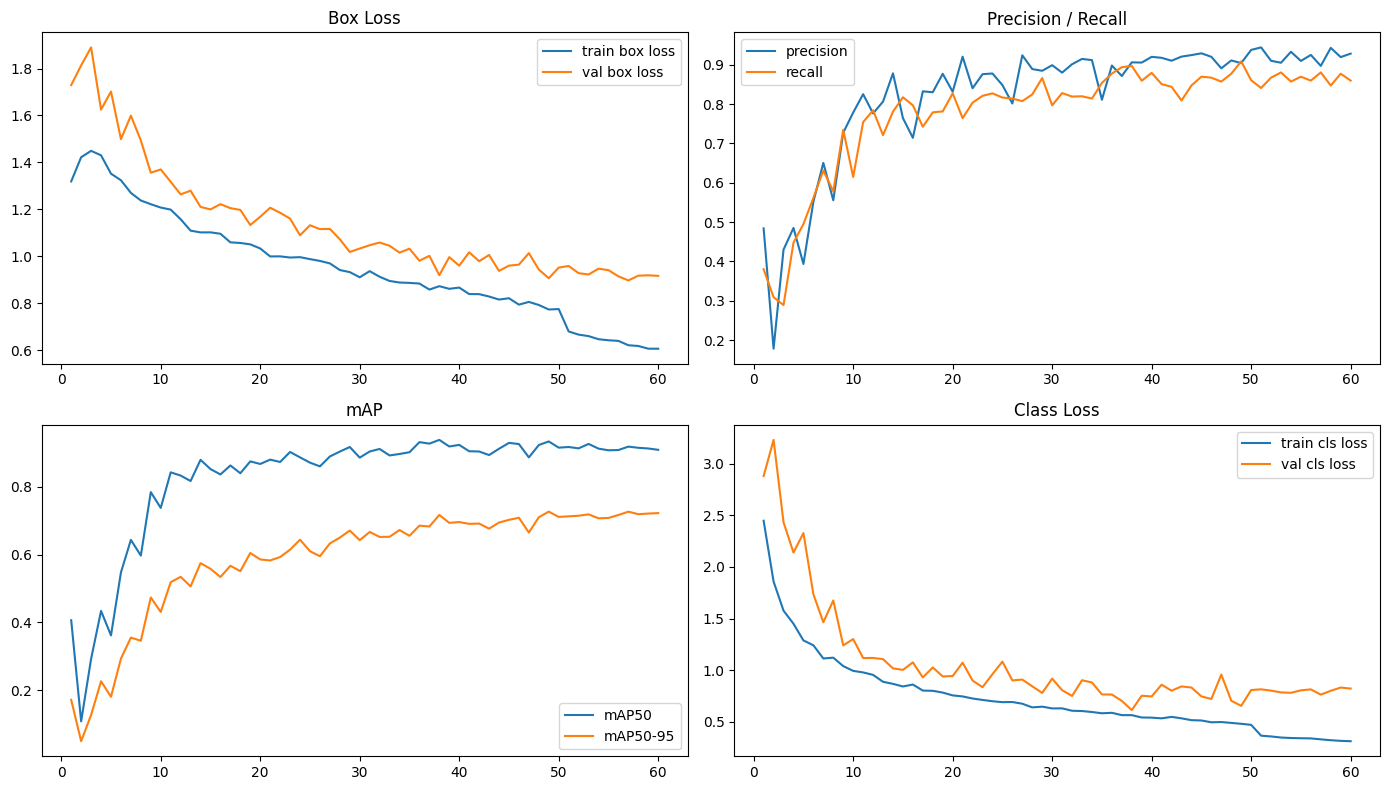

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(df["epoch"], df["train/box_loss"], label="train box loss")
axes[0,0].plot(df["epoch"], df["val/box_loss"], label="val box loss")
axes[0,0].set_title("Box Loss")
axes[0,0].legend()

axes[0,1].plot(df["epoch"], df["metrics/precision(B)"], label="precision")
axes[0,1].plot(df["epoch"], df["metrics/recall(B)"], label="recall")
axes[0,1].set_title("Precision / Recall")
axes[0,1].legend()

axes[1,0].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[1,0].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[1,0].set_title("mAP")
axes[1,0].legend()

axes[1,1].plot(df["epoch"], df["train/cls_loss"], label="train cls loss")
axes[1,1].plot(df["epoch"], df["val/cls_loss"], label="val cls loss")
axes[1,1].set_title("Class Loss")
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Confusion Matrix

Loads the confusion matrix image Ultralytics generated during training, which shows how predictions were distributed across the class and background — useful for spotting whether the model tends to miss detections or produce false positives.

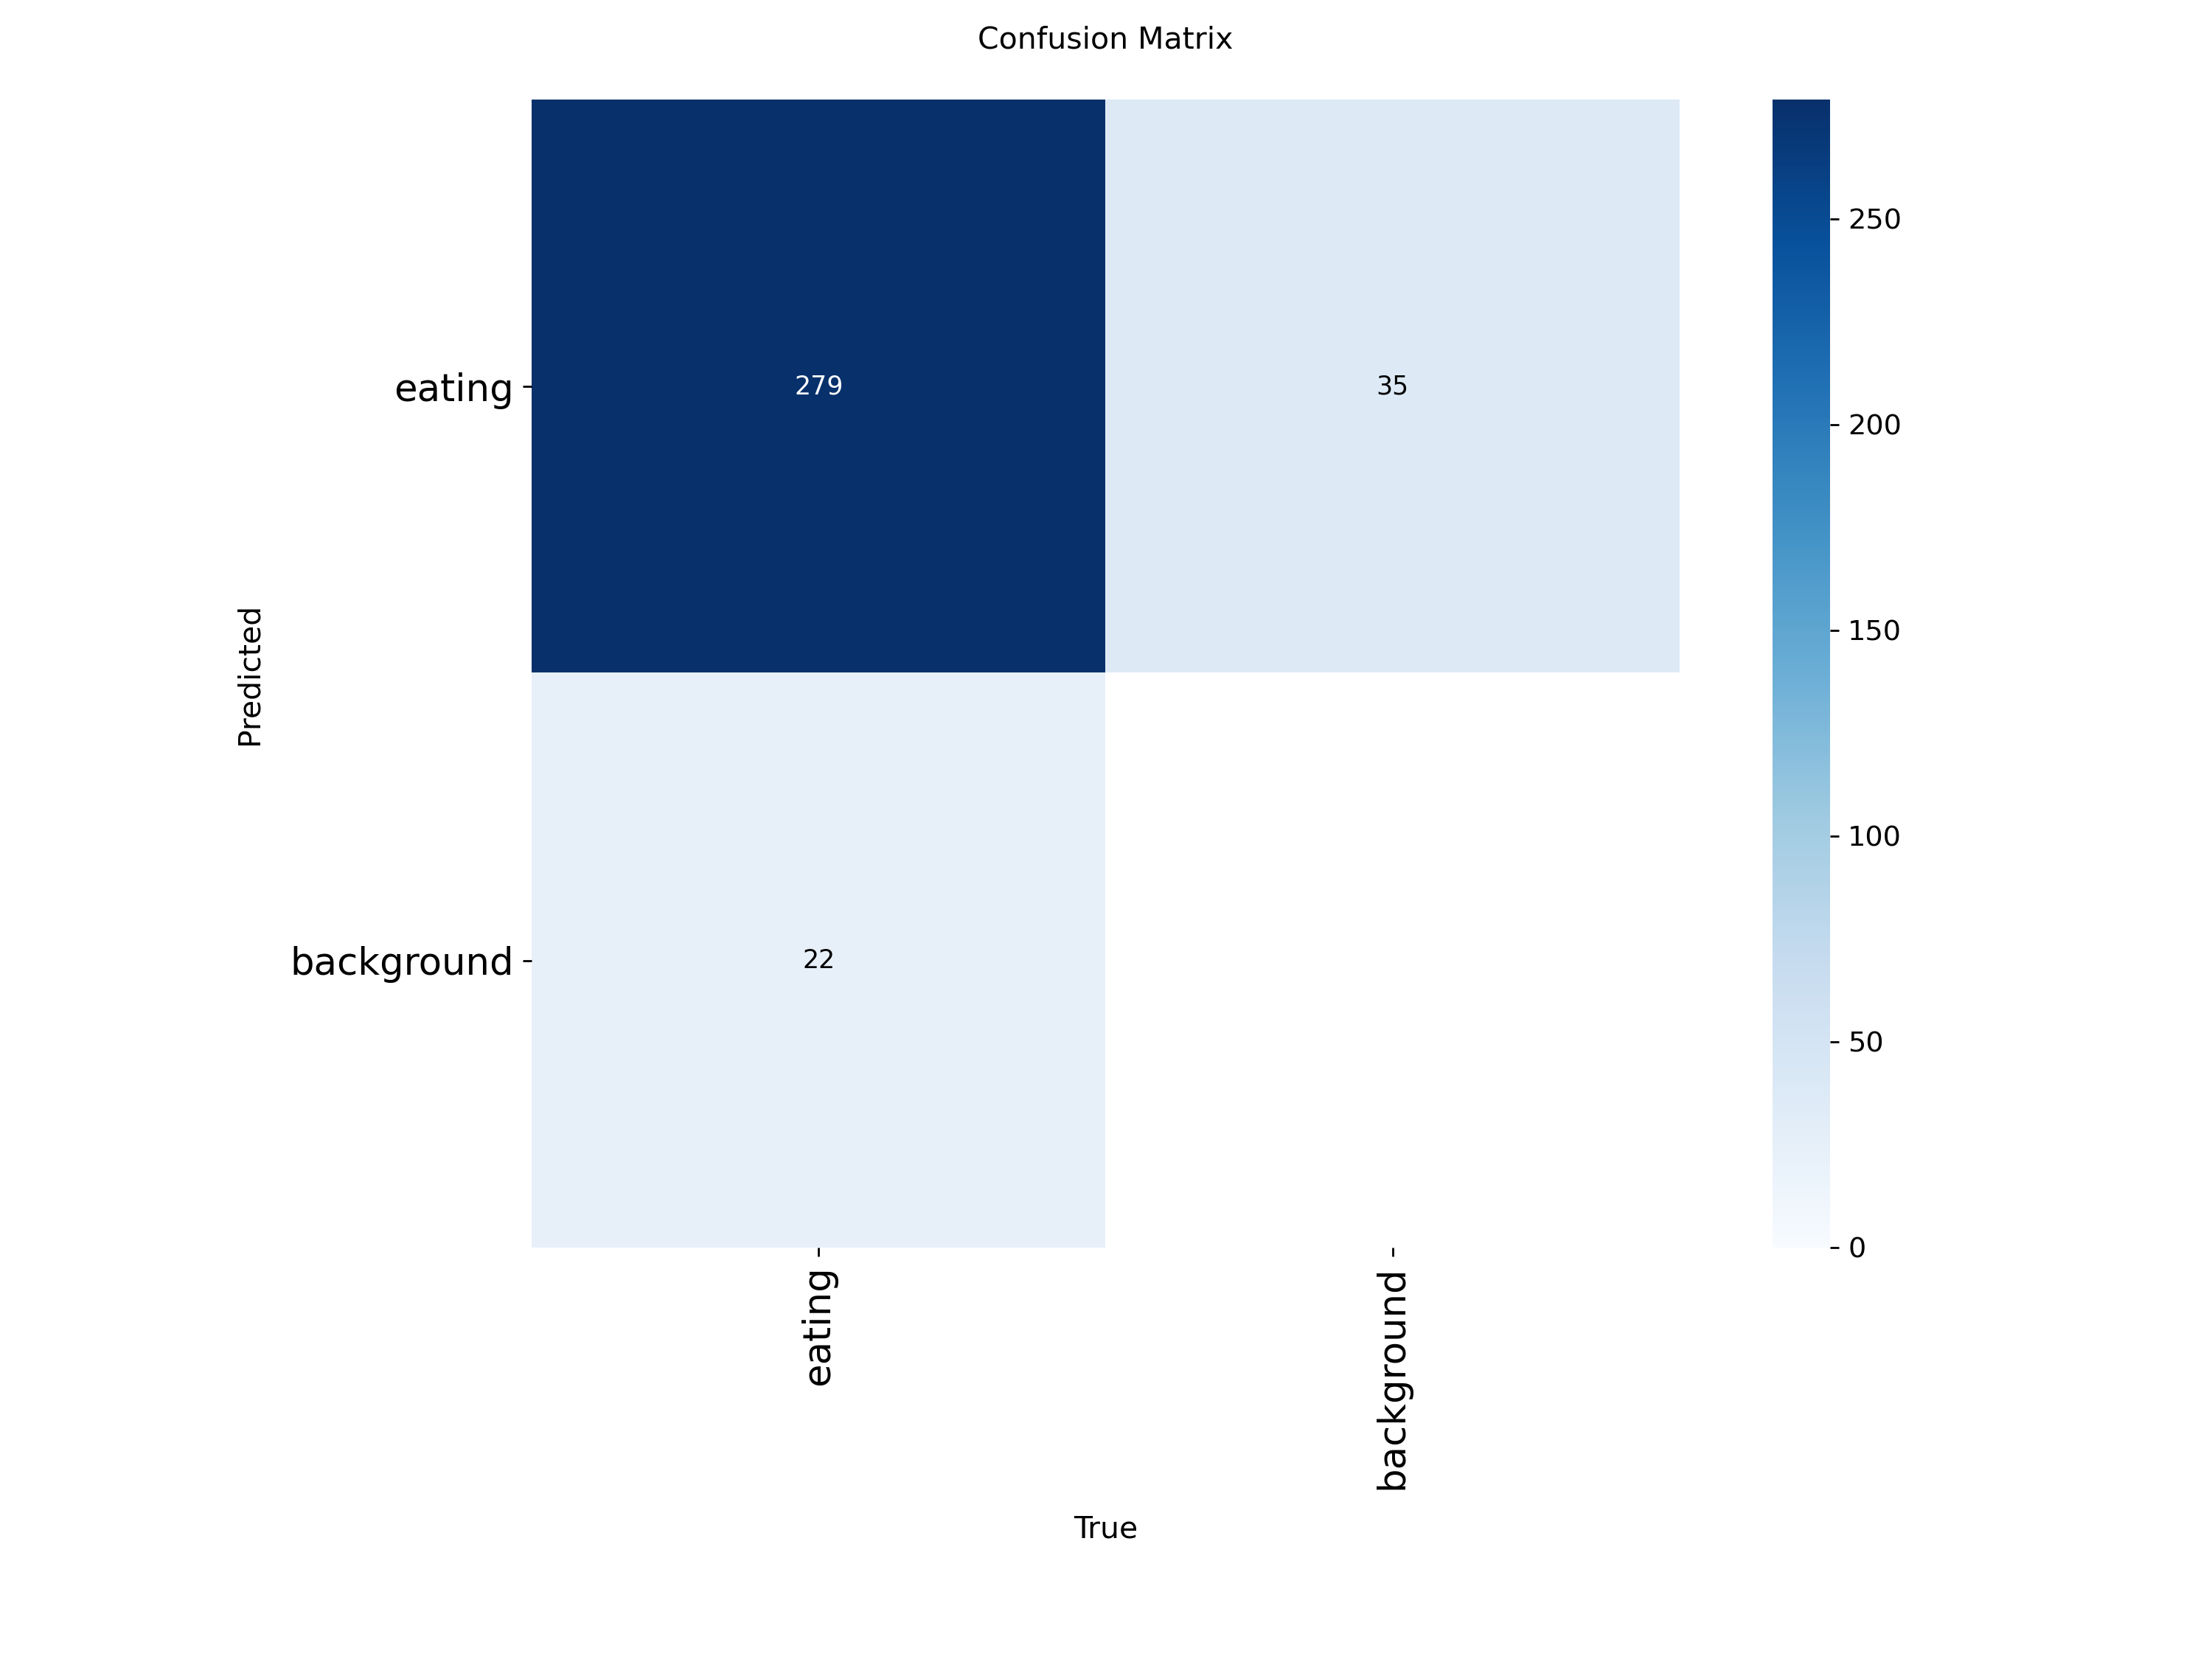

In [10]:
from IPython.display import Image as IPImage

IPImage(filename=os.path.join(run_dir, "confusion_matrix.png"))

### Best Metrics Summary

Pulls out the best mAP50 / mAP50-95 achieved during training, along with the precision and recall from the final epoch. These numbers are the quantitative summary of this module's training run.

In [11]:
print("best mAP50:", df["metrics/mAP50(B)"].max())
print("best mAP50-95:", df["metrics/mAP50-95(B)"].max())
print("final precision:", df["metrics/precision(B)"].iloc[-1])
print("final recall:", df["metrics/recall(B)"].iloc[-1])

best mAP50: 0.93765
best mAP50-95: 0.72644
final precision: 0.92826
final recall: 0.85972


## 5. Test on Test Set Images

With training done, the best checkpoint (`best.pt`) is reloaded and evaluated on the held-out test split — this is the most honest estimate of how the model performs, since the test images were never seen during training or validation.

In [12]:
best_model_path = os.path.join(run_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path, split="test")
print(metrics.box.map50, metrics.box.map)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1479.3±510.5 MB/s, size: 49.3 KB)
val: Scanning /content/Eating-and-Drinking--6/test/labels... 66 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 66/66 2.1Kit/s 0.0s
val: New cache created: /content/Eating-and-Drinking--6/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2it/s 2.3s
                   all         66         66       0.94      0.956      0.983      0.738
Speed: 11.1ms preprocess, 6.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val
0.9825969873779472 0.737716610020261


### Visual Check on Sample Test Images

Runs the model on 6 random test images and plots the predicted boxes, to get a qualitative sense of the results beyond the raw mAP number.


0: 640x640 1 eating, 11.3ms
1: 640x640 2 eatings, 11.3ms
2: 640x640 3 eatings, 11.3ms
3: 640x640 1 eating, 11.3ms
4: 640x640 1 eating, 11.3ms
5: 640x640 1 eating, 11.3ms
Speed: 2.9ms preprocess, 11.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


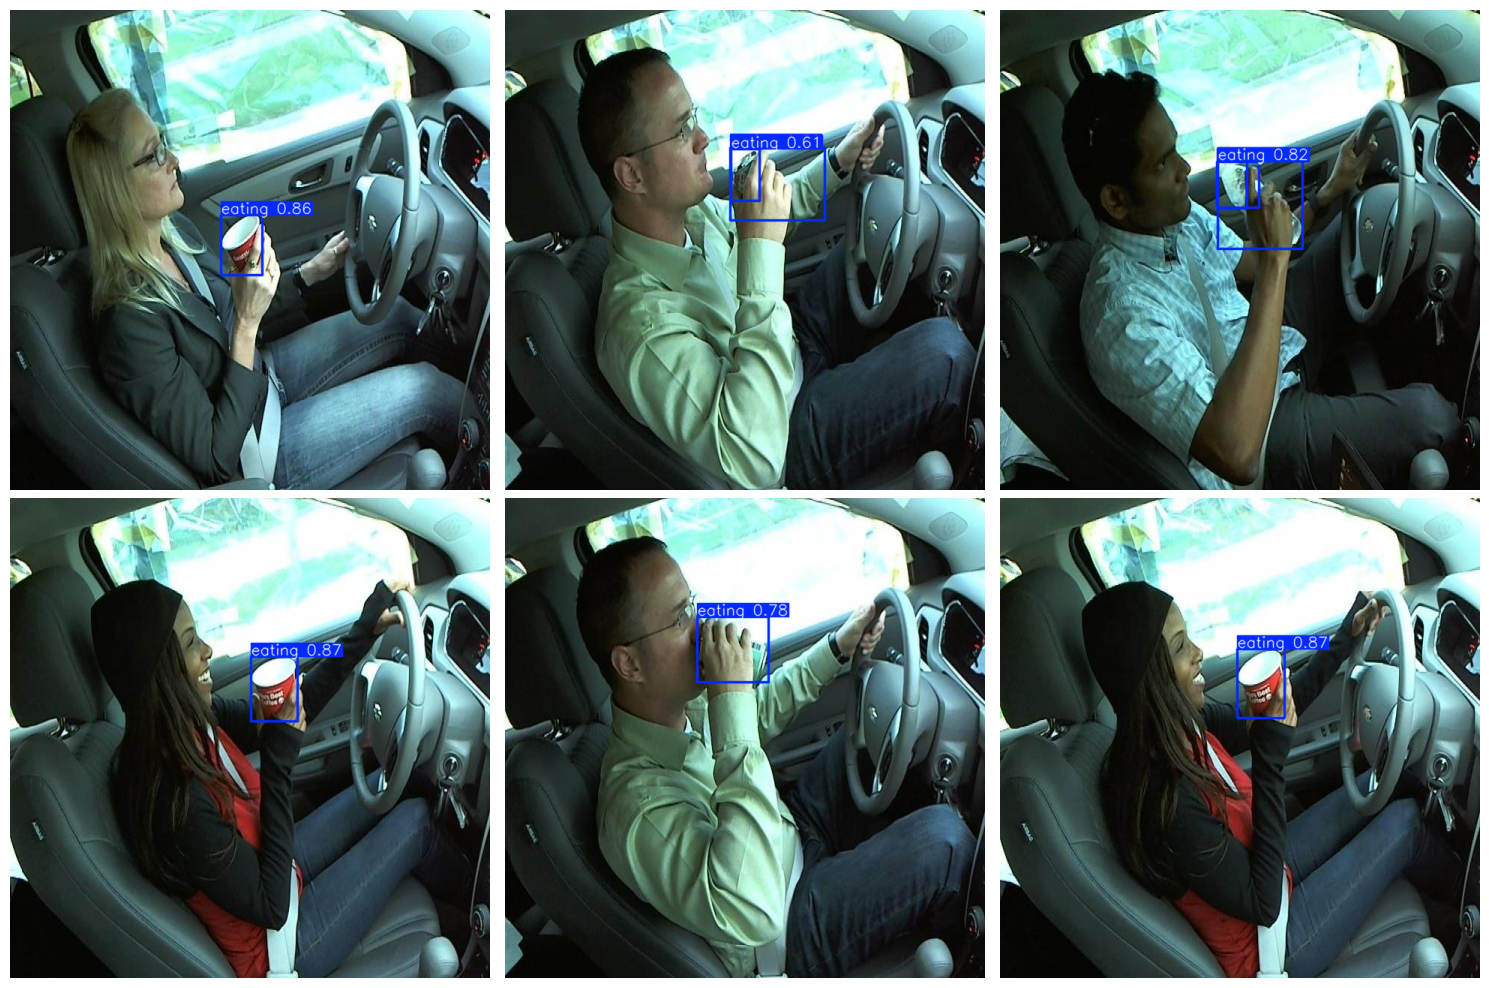

In [13]:
test_images_dir = os.path.join(dataset.location, "test", "images")
test_images = glob.glob(os.path.join(test_images_dir, "*.jpg")) + glob.glob(os.path.join(test_images_dir, "*.png"))
sample_test = random.sample(test_images, min(6, len(test_images)))

preds = best_model.predict(sample_test, conf=0.25)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, pred in zip(axes.flatten(), preds):
    ax.imshow(pred.plot()[:, :, ::-1])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Test on an External Image

As a final check, the model is run on a single image outside the dataset entirely (path set manually below) to see how it generalizes to an arbitrary photo. Each detected box is printed with its class and confidence alongside the visualized result.


image 1/1 /content/images (2).jpg: 480x640 2 eatings, 243.9ms
Speed: 20.2ms preprocess, 243.9ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)


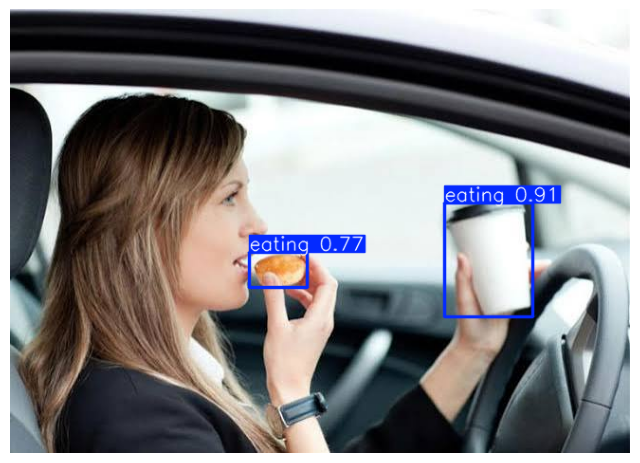

class: eating, confidence: 0.91
class: eating, confidence: 0.77


In [15]:
external_image_path = "/content/images (2).jpg"  # replace with your own path or URL

result = best_model.predict(external_image_path, conf=0.25)[0]

plt.figure(figsize=(8, 8))
plt.imshow(result.plot()[:, :, ::-1])
plt.axis("off")
plt.show()

for box in result.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"class: {result.names[cls_id]}, confidence: {conf:.2f}")

## Summary and Conclusion

This notebook trained a YOLOv8n detector for the eating/drinking behavior class using a Roboflow-hosted dataset. The workflow followed the same pattern used for the other DMS modules: inspect the dataset visually before training, train with early stopping, review the loss/metric curves and confusion matrix afterward, then evaluate on the test set and a manually supplied external image.

Together with the smoking, seatbelt, and drowsiness modules, this gives four behavior-detection components trained independently. A larger backbone (e.g. `yolov8s` or `yolov8m`) could be tried later if the nano model's accuracy turns out to be a bottleneck once all modules are combined into the final DMS pipeline.